# SAXS Analysis Tutorial

The purpose of this notebook is to assist users with classes contained in SAXSAnalysis library. This library contains several Python files, each of them containing dedicated classes.

SAXSAnalysis currently accepts files from 3 different instruments (ESRF, LGC, SWING). Other file formats can be further added by adding the corresponding class in filereaders.py.

Different tasks are separated in dedicated classes, to bring flexibility. Although it may seem more complicated to use, it will allow to modify the code in the future, without having to rewrite everything. These tasks are the following:

### *SAXSProcessor*
 -> class dedicated to data inspection and processing. It allows:

    - Optimized (automatic) reference substraction

    - Automatic caving (image reconstruction based on inversion symmetry)

    - 2D data visualization (q scale)

    - export to sasview

    - extraction of radial profiles in user specified azimuthal directions

    - extraction of azimuthal profiles 

### *CylinderFormFactor*
 -> class dedicated to the calculation of the 2D form factor of a cylinder. It allows:

    - Computation of 2D form factor in q space

    - extraction of azimuthal profile at a given q value

### *NematicOrderCalculator*
 -> class dedicated to the calculation of nematic order parameter. It allows:

    - refinement of experimental azimuthal profiles by th convolution of form factor and Maier-Saupe distribution

### *CorrelationDistanceCalculator (shoud be improved)*
 -> class dedicated to the computation of correlation distances. It allows:

    - determination of peak positions in q space (based on 2nd derivative)

    - calculation of correlation distances

### Test case

The test proposed here is performed on ESRF Data, recorded on ID02. The experiment consists in the alignment of Co12 NRs in toluene, un der a magnetic field. 


The program should work without any problems for LGC data.
For SWING data, results should be double checked, as 2x2 pixels binning is applied.


In [ ]:
%matplotlib widget
from saxsprocessor import SAXSProcessor
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

## Define sample files 

As a start, test is performed on a single file. On this file, we will:
- substract reference with optimized code (same procedure as ReduSAXS)
- perform a nice 2D plot $(Q_x,Q_z)$ scale
- extract radial and azimuthal profiles
- compute nematic order parameter

In [ ]:
# Define instrument, sample files and paths

instrument='ID02'
mask = './test_data/ref_mask/mask_saxs.edf'
file = './test_data/LPCNOsaxs_eiger2_00533_raw.h5'
reference = './test_data/ref_mask/LPCNOsaxs_eiger2_00467_raw.h5'
output_dir='./test_output/'
os.makedirs(output_dir,exist_ok=True)

# create instance of SAXSDataProcessor
processor = SAXSProcessor(instrument=instrument, file=file, reference_file=reference,autosubstract=True, mask=mask)


# call plot2d_vsq method
#processor.plot2d_vsq(q_range = [0, 0.2],cmap='jet',normalize = True, vmin=-4, output_dir = output_dir)

# extract radial profile
q_radial, intensity_radial_90 = processor.extract_radial_profile(azimuth=90, width=20, save = True,output_dir=output_dir)
q_radial, intensity_radial_0 = processor.extract_radial_profile(azimuth=0, width=20, save = True, output_dir=output_dir)
plt.figure()
plt.loglog(q_radial, intensity_radial_90, label='Azimuth=90°')
plt.loglog(q_radial, intensity_radial_0, label='Azimuth=0°')
plt.xlabel('$Q (\AA^{-1})$')
plt.ylabel('Intensity (a.u.)')
plt.title('Radial Profile')
plt.legend()

# extract azimuthal profile at specific Q
q_value = 0.034
threshold=0.01
chi_exp , I_az_exp = processor.extract_azimuthal_profile(qvalue=q_value, threshold=threshold, output_dir=output_dir)
plt.figure()
plt.plot(chi_exp, I_az_exp, label=f'Q={q_value} $\AA^{{-1}}$')
plt.xlabel('Azimuthal Angle (degrees)')
plt.ylabel('Intensity (a.u.)')
plt.title(f'Azimuthal Profile at Q={q_value} $\AA^{{-1}}$')
plt.legend()


# export data for further use in sasview
processor.export_sasview(output_dir=output_dir)

## Cylinder form factor calculation

At first, we must compute the cylinder form factor (based on sasview). Default parameters correspond to those of Co12 particles, but they may be changed as desired.

The azimuthal profile of form factor will be further convoluted with a Maier Saupe distribution in order to compute the nematic order parameter. 
The CylinderFormFactor class computes the 2D form factor of polydisperse cylinders, WITHOUT any orientation distribution. The orientation distribution is further accounted for by the Maier Saupe distribution, from which is computed the nematic order parameter S.

In [ ]:
from nematicordercalculator import CylinderFormFactor,NematicOrderCalculator

form_factor = CylinderFormFactor(
    processor=processor, 
    radius=78,
    L=840,
    theta=90,
    phi=0.4,
    radius_pd=0.3,
    L_pd=0.75,
    phi_pd=0,
    theta_pd=0,
    background=0.00001,
    scale=1,
    plot = True
    )

### Azimuthal profile extraction at given q (may be useful)
For good practice, it is shown here how to extract azimuthal profiles at a given q value, without having to recompute the 2D form factor

In [ ]:
I2D = form_factor.I_ff2D
chi2,I2 = form_factor.extract_azim_profile_formfactor(I2D, q0=0.034, threshold=threshold, plot=True)

### Computation of nematic order parameter @ q = 0.034

Refinement of the experimental aimuthal profile $(\chi_{exp}, I_{az,exp})$ with the convolution of the azimuthal profile of the form factor with Maier Saupe distribution

In [ ]:
nematic_calc = NematicOrderCalculator(form_factor=form_factor)

results = nematic_calc.fit_azimuthal_profile(chi_exp, I_az_exp, qvalue_ff=0.034, threshold_ff=threshold, plot=True, target=90, apply_mirror=False)
print(f'Nematic order parameter S2 = {results["S"]:.3f} ')

## Test BatchNematic class (automatic batch)

performs the calculation of nematic order parameter on a serie of data files contained in a directory supplied by the user.

### 1. Calculation of Cylinder Formfactor

✓ Detector geometry inherited from Co12_tol1
  - Detector: 2162 x 2068 pixels
  - Pixel size: 0.075 mm
  - Distance: 1.400 m
  - Wavelength: 1.01377 Å

Computing Q grids...
Computing 2D cylinder form factor...


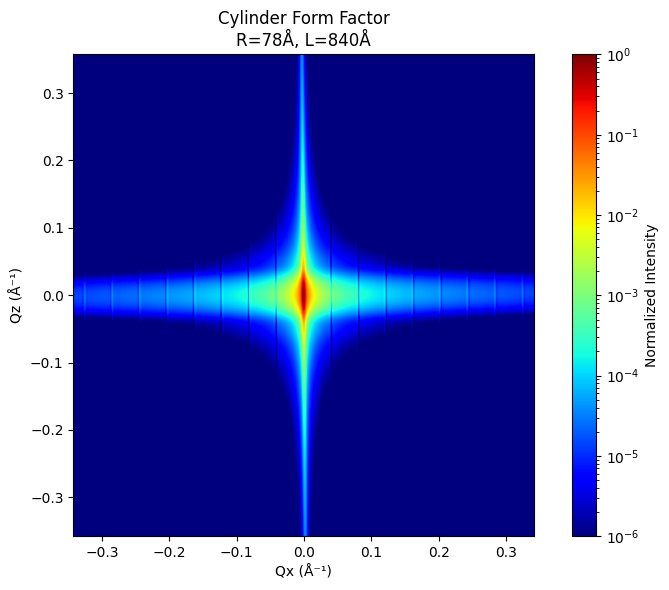

✓ Form factor computed (shape: (4471016,))

Note: Azimuthal profiles will be extracted by BatchNematic for each q value


In [1]:
from saxsprocessor import SAXSProcessor
from nematicordercalculator import BatchNematic, CylinderFormFactor,NematicOrderCalculator
# sect q values and threshold at which to extract azimuthal profiles
q_value = 0.034
threshold=0.01


# ----- 1) compute cylinder form factor

# CylinderFormFactor needs a SAXSProcessor instance to get q-mesh and other instrument parameters
file = './test_data/LPCNOsaxs_eiger2_00533_raw.h5' # select a random file for initialization
instrument='ID02'

processor = SAXSProcessor(instrument=instrument, file=file)

form_factor = CylinderFormFactor(
    processor=processor, 
    radius=78,
    L=840,
    theta=90,
    phi=0.4,
    radius_pd=0.3,
    L_pd=0.75,
    phi_pd=0,
    theta_pd=0,
    background=0.00001,
    scale=1,
    plot = True)

### 2. Run Batch

✓ NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q

BatchNematic initialized
Path: ./test_data
Q values: [0.034, 0.068]
Found 7 files to process
Output directory: ./test_output/batch_nematic/


Processing: LPCNOsaxs_eiger2_00528_raw.h5
Optimized k factor for reference subtraction: 0.09661731

Processing q = 0.0340 Å⁻¹...


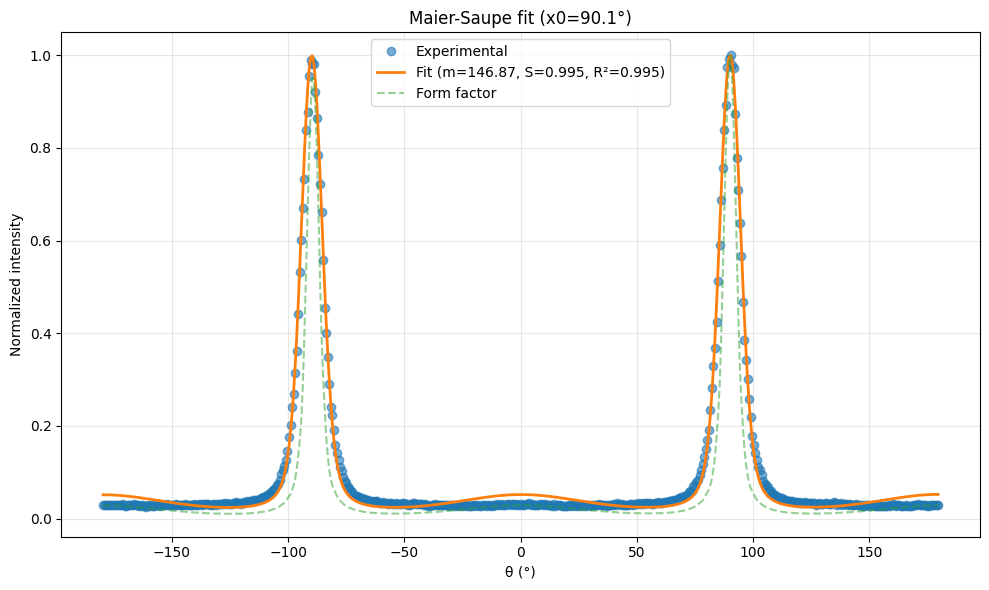

x0: 90.09051120192339
S: 0.9948934025455768
R2: 0.9945690734958753
  ✓ Success | q=0.0340 | S=0.9949 | m=146.87 | R²=0.9946

Processing q = 0.0680 Å⁻¹...


/home-local/ratel-ra/anaconda3_c/envs/py311/lib/python3.11/site-packages/pyFAI/azimuthalIntegrator.py:1670: RuntimeWarning: invalid value encountered in divide
  intensity = sum_signal / sum_normalization


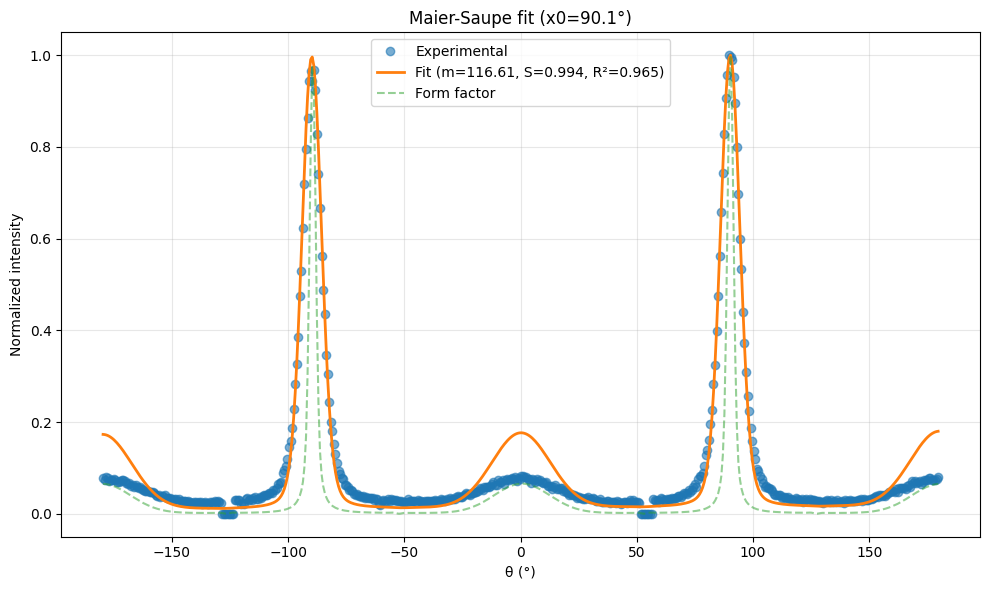

x0: 90.09304090549381
S: 0.9935685302260353
R2: 0.965350306931063
  ✓ Success | q=0.0680 | S=0.9936 | m=116.61 | R²=0.9654

Processing: LPCNOsaxs_eiger2_00529_raw.h5
Optimized k factor for reference subtraction: 0.0903595

Processing q = 0.0340 Å⁻¹...


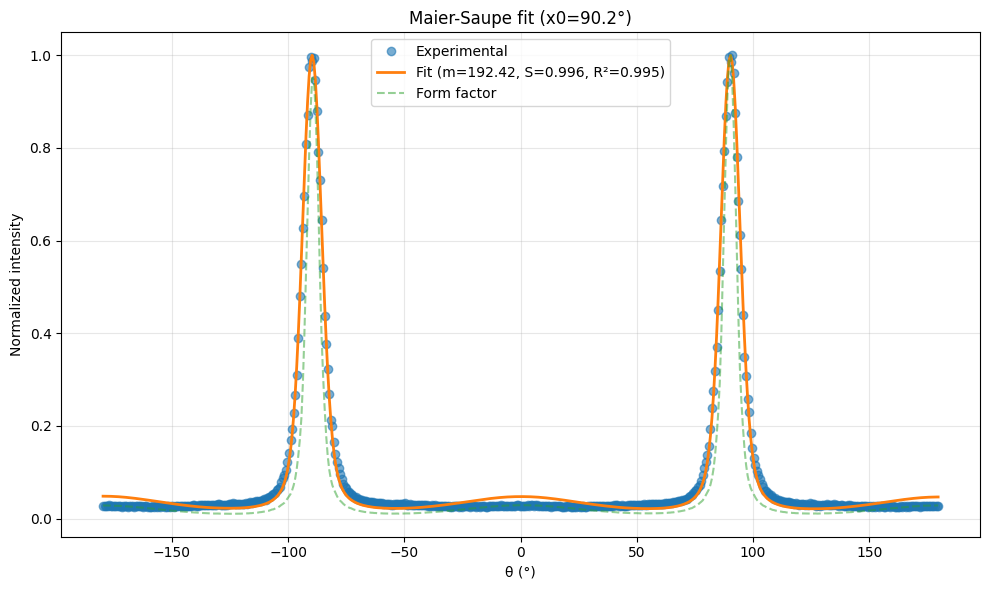

x0: 90.218061966721
S: 0.996102181219503
R2: 0.9954781056616391
  ✓ Success | q=0.0340 | S=0.9961 | m=192.42 | R²=0.9955

Processing q = 0.0680 Å⁻¹...


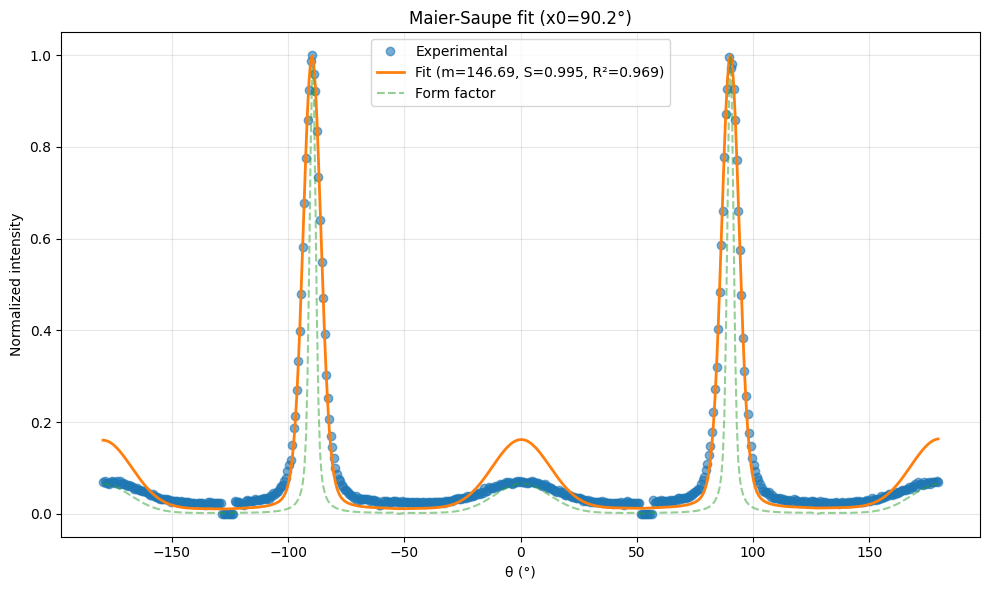

x0: 90.18353866873696
S: 0.9948871340563866
R2: 0.9692605958486054
  ✓ Success | q=0.0680 | S=0.9949 | m=146.69 | R²=0.9693

Processing: LPCNOsaxs_eiger2_00530_raw.h5
Optimized k factor for reference subtraction: 0.08857801

Processing q = 0.0340 Å⁻¹...


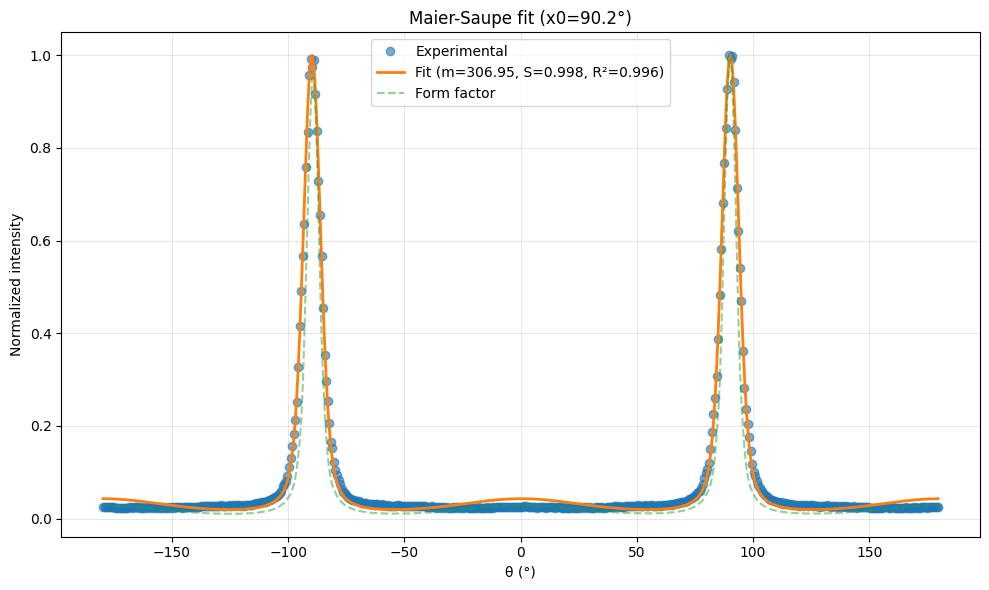

x0: 90.1598550306644
S: 0.9975565976543332
R2: 0.9958142136265923
  ✓ Success | q=0.0340 | S=0.9976 | m=306.95 | R²=0.9958

Processing q = 0.0680 Å⁻¹...


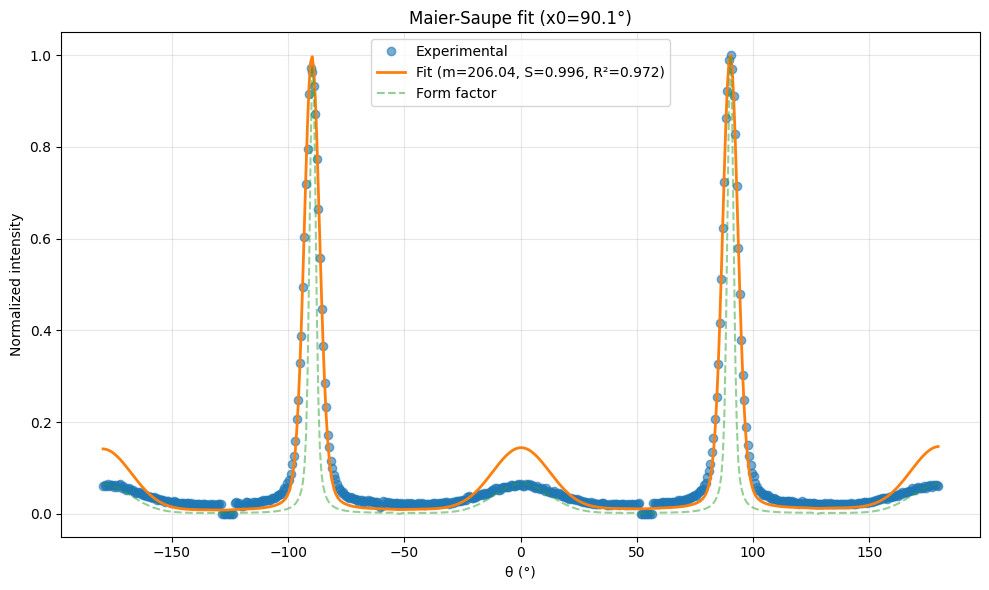

x0: 90.12990570388558
S: 0.9963599454695754
R2: 0.9724074489420146
  ✓ Success | q=0.0680 | S=0.9964 | m=206.04 | R²=0.9724

Processing: LPCNOsaxs_eiger2_00531_raw.h5
Optimized k factor for reference subtraction: 0.08618981

Processing q = 0.0340 Å⁻¹...


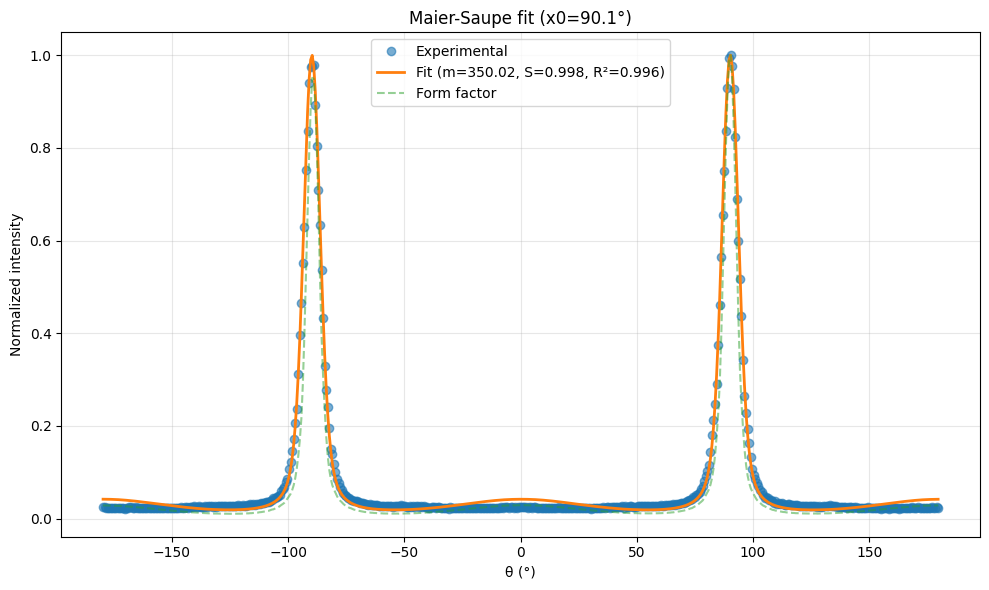

x0: 90.12955763148295
S: 0.9978572665064991
R2: 0.996017978489045
  ✓ Success | q=0.0340 | S=0.9979 | m=350.02 | R²=0.9960

Processing q = 0.0680 Å⁻¹...


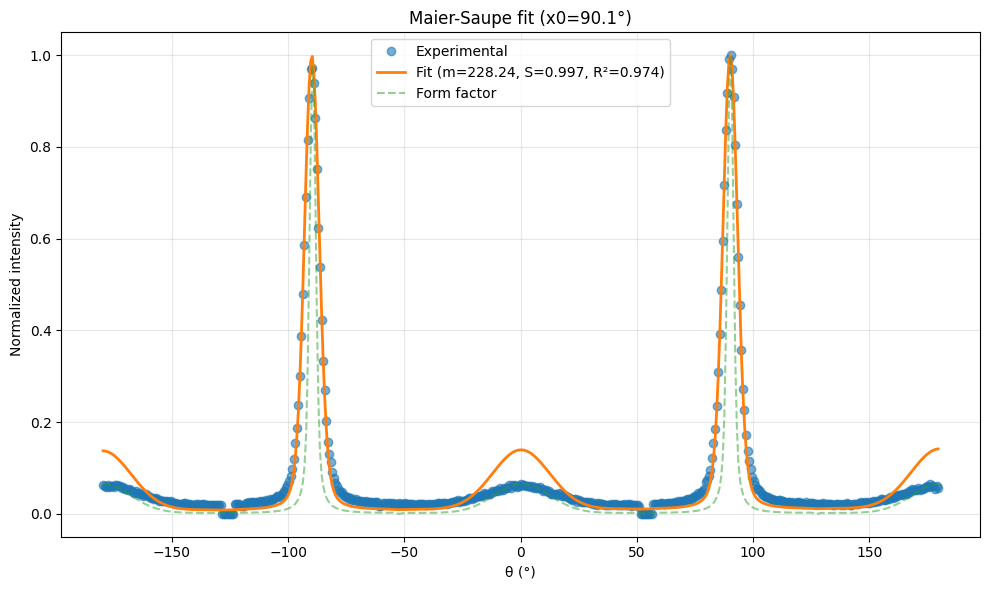

x0: 90.10600233080925
S: 0.9967139390016437
R2: 0.9735080165958484
  ✓ Success | q=0.0680 | S=0.9967 | m=228.24 | R²=0.9735

Processing: LPCNOsaxs_eiger2_00532_raw.h5
Optimized k factor for reference subtraction: 0.086584724

Processing q = 0.0340 Å⁻¹...


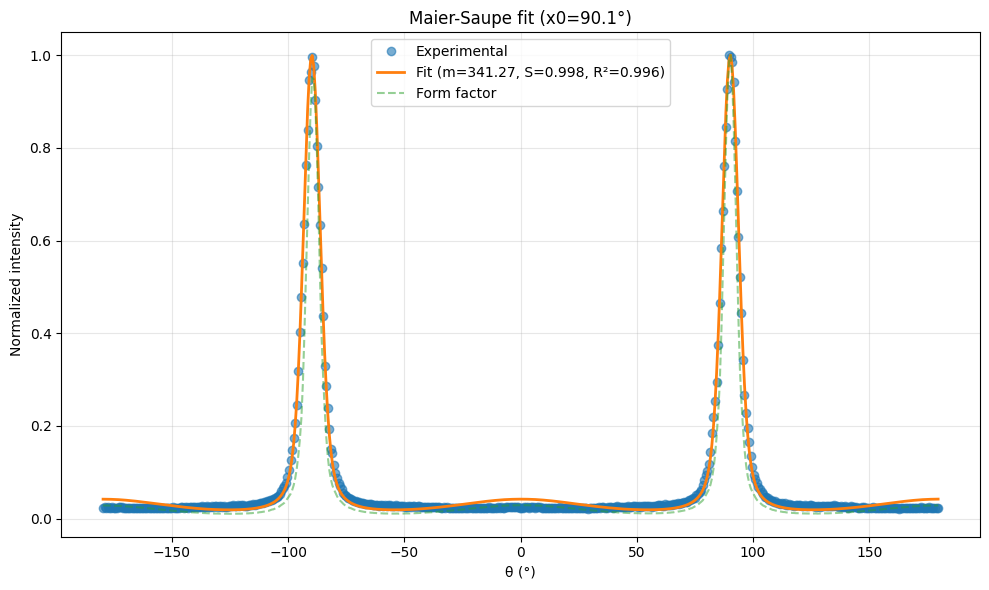

x0: 90.11916568172205
S: 0.9978022951244976
R2: 0.9960291196966122
  ✓ Success | q=0.0340 | S=0.9978 | m=341.27 | R²=0.9960

Processing q = 0.0680 Å⁻¹...


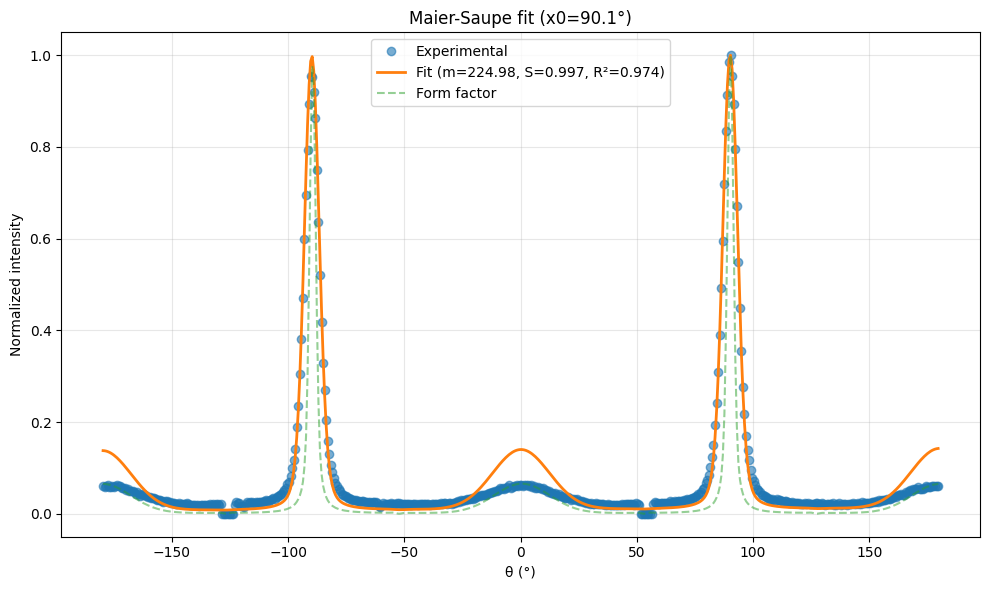

x0: 90.0935847946231
S: 0.9966663152019718
R2: 0.9737198645124635
  ✓ Success | q=0.0680 | S=0.9967 | m=224.98 | R²=0.9737

Processing: LPCNOsaxs_eiger2_00533_raw.h5
Optimized k factor for reference subtraction: 0.08581974

Processing q = 0.0340 Å⁻¹...


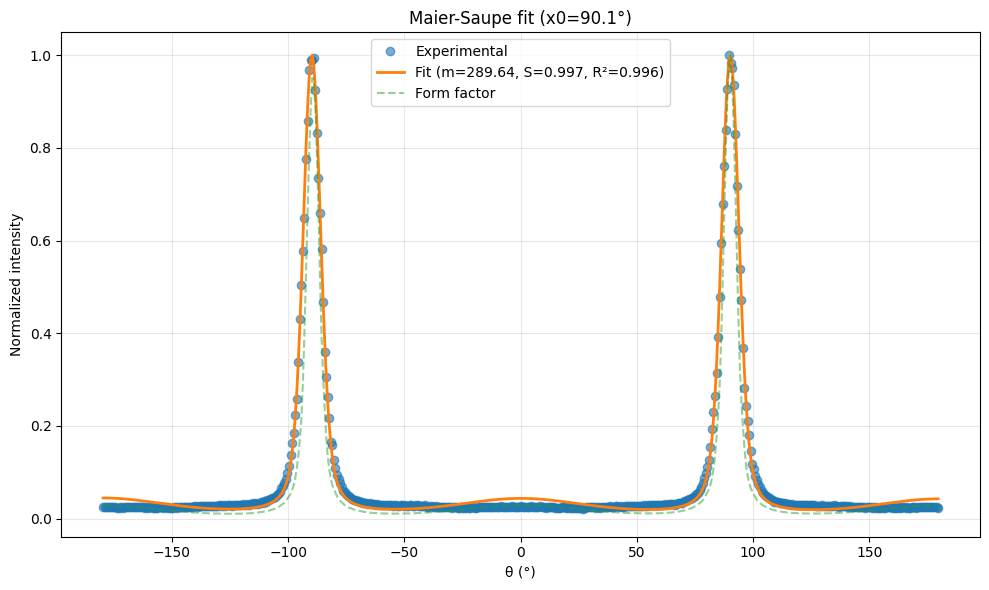

x0: 90.14592946417042
S: 0.9974105644390616
R2: 0.9957200829447129
  ✓ Success | q=0.0340 | S=0.9974 | m=289.64 | R²=0.9957

Processing q = 0.0680 Å⁻¹...


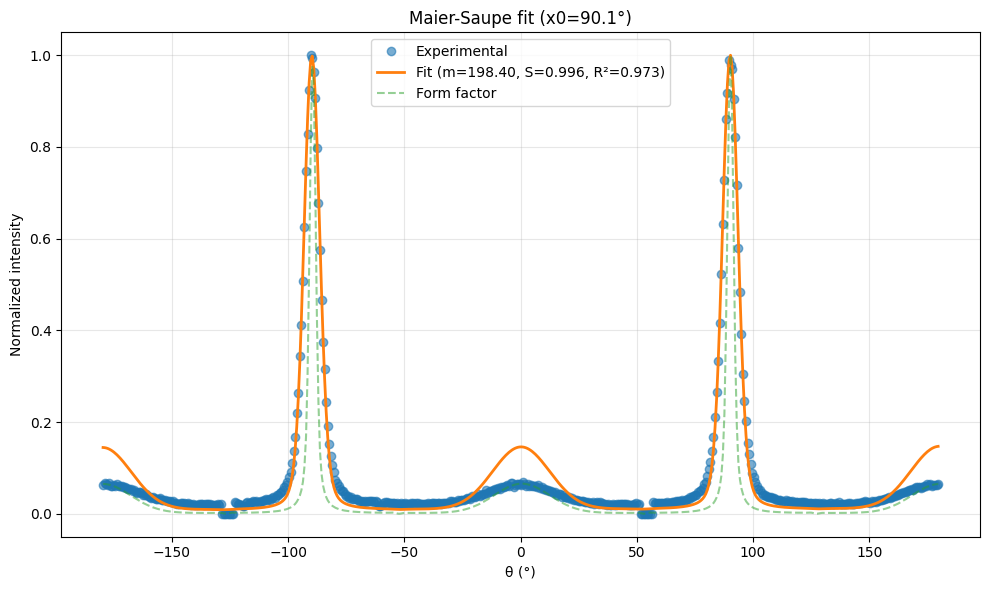

x0: 90.12549592954531
S: 0.9962198372125343
R2: 0.9725451752256051
  ✓ Success | q=0.0680 | S=0.9962 | m=198.40 | R²=0.9725

Processing: LPCNOsaxs_eiger2_00534_raw.h5
Optimized k factor for reference subtraction: 0.08372588

Processing q = 0.0340 Å⁻¹...


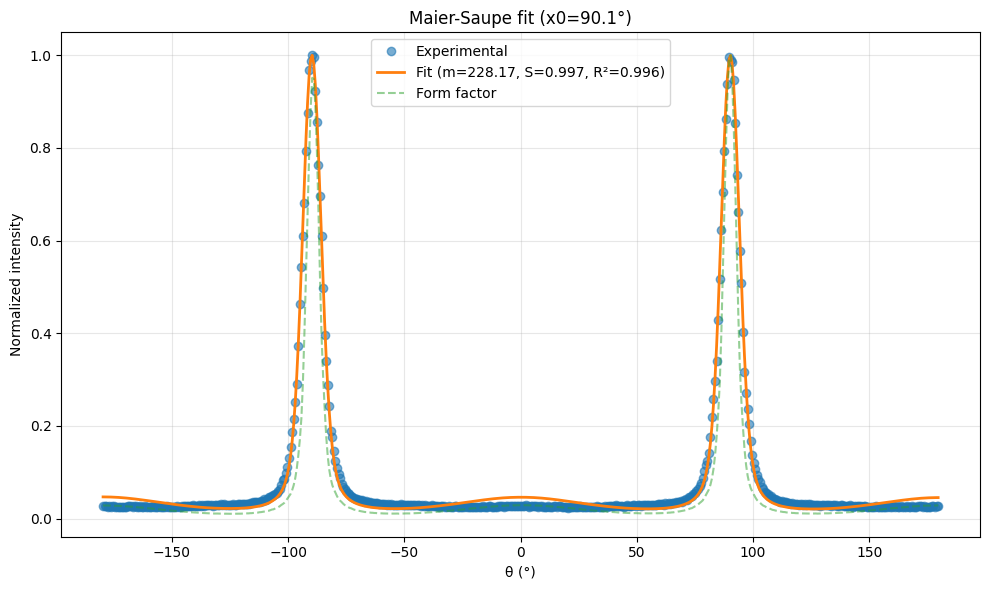

x0: 90.14459467970312
S: 0.9967130308068672
R2: 0.9955593104422807
  ✓ Success | q=0.0340 | S=0.9967 | m=228.17 | R²=0.9956

Processing q = 0.0680 Å⁻¹...


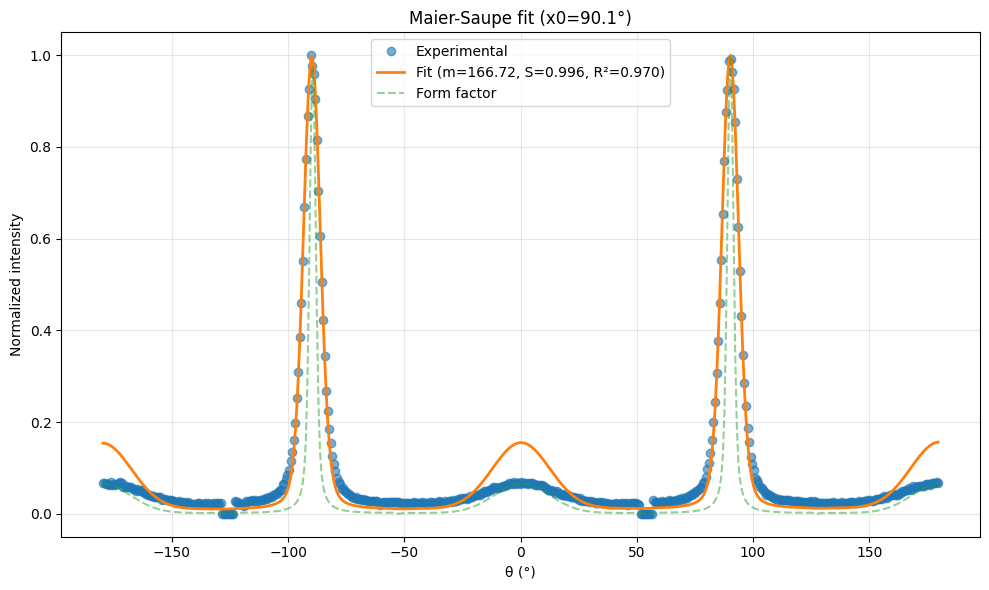

x0: 90.11401272671992
S: 0.9955013571250867
R2: 0.969908538495301
  ✓ Success | q=0.0680 | S=0.9955 | m=166.72 | R²=0.9699

Saving results...
✓ Log file saved: ./test_output/batch_nematic/batch_processing.log
✓ Results CSV saved: ./test_output/batch_nematic/nematic_order_results.csv

Summary Statistics
Total files processed: 7
Successful fits: 14
Failed fits: 0

Nematic Order Parameter (S) statistics:
  q = 0.0340 Å⁻¹:
    Mean S = 0.9969 ± 0.0011
    Range: [0.9949, 0.9979]
  q = 0.0680 Å⁻¹:
    Mean S = 0.9957 ± 0.0011
    Range: [0.9936, 0.9967]



,File,Sample,B (mT),File_Number,q (Å⁻¹),S,m,x0 (°),I0,a (slope),b (offset),R²
0,LPCNOsaxs_eiger2_00528_raw.h5,Co12_tol1,100,528,0.034,0.994893,146.868831,90.090511,0.000958,2.312790e-06,0.006860,0.994569
1,LPCNOsaxs_eiger2_00528_raw.h5,Co12_tol1,100,528,0.068,0.993569,116.614091,90.093041,0.014621,1.839886e-05,0.009164,0.965350
2,LPCNOsaxs_eiger2_00529_raw.h5,Co12_tol1,400,529,0.034,0.996102,192.415308,90.218062,0.000906,-4.561008e-06,0.005530,0.995478
3,LPCNOsaxs_eiger2_00529_raw.h5,Co12_tol1,400,529,0.068,0.994887,146.688767,90.183539,0.013496,7.919486e-06,0.007144,0.969261
4,LPCNOsaxs_eiger2_00530_raw.h5,Co12_tol1,1000,530,0.034,0.997557,306.949038,90.159855,0.000817,-1.856567e-07,0.004901,0.995814
5,LPCNOsaxs_eiger2_00530_raw.h5,Co12_tol1,1000,530,0.068,0.996360,206.040869,90.129906,0.011902,1.437007e-05,0.006302,0.972407
6,LPCNOsaxs_eiger2_00531_raw.h5,Co12_tol1,1400,531,0.034,0.997857,350.020197,90.129558,0.000791,-3.921733e-07,0.004621,0.996018
7,LPCNOsaxs_eiger2_00531_raw.h5,Co12_tol1,1400,531,0.068,0.996714,228.236786,90.106002,0.011500,1.124302e-05,0.006102,0.973508
8,LPCNOsaxs_eiger2_00532_raw.h5,Co12_tol1,1000,532,0.034,0.997802,341.265112,90.119166,0.000799,4.161563e-07,0.004664,0.996029
9,LPCNOsaxs_eiger2_00532_raw.h5,Co12_tol1,1000,532,0.068,0.996666,224.976279,90.093585,0.011428,1.258098e-05,0.006093,0.973720


In [2]:
# select data path, reference file, mask, qvalues, threshold
path = './test_data'
reference = './test_data/ref_mask/LPCNOsaxs_eiger2_00467_raw.h5'
mask = './test_data/ref_mask/mask_saxs.edf'
qvalues = [0.034, 0.068]
threshold=0.01
output_dir='./test_output/batch_nematic/'

batch= BatchNematic(
    instrument=instrument,
    path=path,
    qvalues=qvalues,
    threshold=threshold,
    reference_file=reference,
    autosubstract=True,
    mask=mask,
    file_filter = '*eiger2_005*.h5', #ensures we select only sample files
    form_factor=form_factor,    
    output_dir=output_dir
)
batch.process_all(save_profiles=True,plot =True)